
# Numerical solver

Data and 

In [1]:
include("subcrit_solver.jl")

angle_check (generic function with 1 method)

In [2]:
ve = 0
n=150
len = sqrt(pi)*pi/2
A = vel_opti(ve,len,5*len,150,false)



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:   317166
Number of nonzeros in inequality constraint Jacobian.:     2312
Number of nonzeros in Lagrangian Hessian.............:     6536

Total number of variables............................:    91204
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    89156
Total number of inequality c

([0.0 0.0 … 0.0 0.0; 0.0 -2.634548120779724e-29 … 5.076619144404388e-29 0.0; … ; 0.0 7.466307005603486e-31 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 -2.851863506908077e-30 … 5.571315292461005e-32 0.0; … ; 0.0 7.622628108208497e-29 … -9.756422136653683e-31 0.0; 0.0 0.0 … 0.0 0.0], [0.05249973290931773 0.042417249795565645 … 0.012305206965781391 0.014317959058565763; 0.04282111978267233 0.03254015201821283 … 0.009935660330263761 0.012003716256653198; … ; 0.06975740649600531 0.060358141565685273 … 0.016505660652118826 0.018357721271945363; 0.07862581462207774 0.06954044006627476 … 0.0189103356793325 0.02067917376259954], [-0.14912860556532118 -0.1517395687072 … -0.0338365340073509 -0.03255120101287264; -0.1527613567221901 -0.15471300634969565 … -0.03413951916760171 -0.03300070842226214; … ; -0.13991035841194158 -0.14359752276811524 … -0.032989457146280085 -0.031474588299123564; -0.13447591920836205 -0.13876698009296207 … -0.032199314374850234 -0.030547374497366445], 0.0928054

In [3]:
thrust = x_thrust_Q(1, 151, 1, 151, A[5], A[1], A[2],A[3],A[4])
pwr = q_pwr(1, 151, 1, 151, A[5], A[1], A[2],A[3],A[4],ve)
eff = thrust/pwr

print("Thrust = ", thrust,"\nPower = ", pwr, "\nEff = ", eff)

Thrust = 0.2576743677511574
Power = 0.38407582521342476
Eff = 0.670894523517516

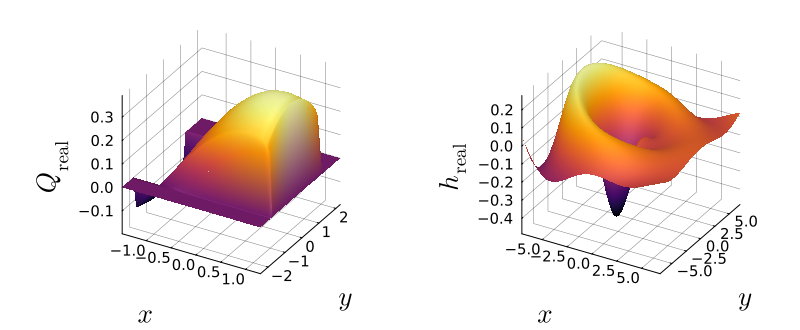

In [16]:
space_array = -5*len/2-A[5]:A[5]:5*len/2
l_i = len
p= plot(surface(space_array, space_array, A[1],zlabel=L"Q_{\textrm{real}}",
        xlims=[-l_i/2-A[5],l_i/2-A[5]],ylims=[-3pi/4-A[5],3pi/4-A[5]]), 
    surface(space_array, space_array, A[3],zlabel=L"h_{\textrm{real}}"),colorbar=false,xlabel=L"x",ylabel=L"y",
    labelfontsize=18,tickfontsize=10,gridalpha=0.5,size=(800,330))
display(p)


### $\mathcal{L}_{v}\hat{Q}=0$ test



In [ ]:
dx = A[5]
l = A[6]
r = A[7]
# n = 150
v = ve
# run the operator L check
check_real = zeros(n,n);
check_imag = zeros(n,n);
# bulk
for i in l+1:r-1
    for j in l+1:r-1
        check_real[i,j] =((1-v^2)*second_centred_x(A[1],dx,i,j)
                            + 2*v*first_centred_x(A[2],dx,i,j) 
                            + second_centred_y(A[1],dx,i,j) 
                            + A[1][i,j])
        check_imag[i,j] =((1-v^2)*second_centred_x(A[2],dx,i,j) 
                            - 2*v*first_centred_x(A[1],dx,i,j)
                            + second_centred_y(A[2],dx,i,j) 
                            + A[2][i,j]) 
    end
end
#edges
for j in l+1:r-1
    check_real[l,j] =((1-v^2)*second_centred_x(A[1],dx,l,j)
                        + 2*v*first_centred_x(A[2],dx,l,j) 
                        + second_forw_y(A[1],dx,l,j) 
                        + A[1][l,j])
    check_imag[l,j] =((1-v^2)*second_centred_x(A[2],dx,l,j) 
                        - 2*v*first_centred_x(A[1],dx,l,j)
                        + second_forw_y(A[2],dx,l,j) 
                        + A[2][l,j]) 
    check_real[r,j] =((1-v^2)*second_centred_x(A[1],dx,r,j)
                        + 2*v*first_centred_x(A[2],dx,r,j) 
                        + second_back_y(A[1],dx,r,j) 
                        + A[1][r,j])
    check_imag[r,j] =((1-v^2)*second_centred_x(A[2],dx,r,j) 
                        - 2*v*first_centred_x(A[1],dx,r,j)
                        + second_back_y(A[2],dx,r,j) 
                        + A[2][r,j]) 
    check_real[j,l] =((1-v^2)*second_forw_x(A[1],dx,j,l)
                        + 2*v*first_forw_x(A[2],dx,j,l) 
                        + second_centred_y(A[1],dx,j,l) 
                        + A[1][j,l])
    check_imag[j,l] =((1-v^2)*second_forw_x(A[2],dx,j,l) 
                        - 2*v*first_forw_x(A[1],dx,j,l)
                        + second_centred_y(A[2],dx,j,l) 
                        + A[2][j,l]) 
    check_real[j,r] =((1-v^2)*second_back_x(A[1],dx,j,r)
                        + 2*v*first_back_x(A[2],dx,j,r) 
                        + second_centred_y(A[1],dx,j,r) 
                        + A[1][j,r])
    check_imag[j,r] =((1-v^2)*second_back_x(A[2],dx,j,r) 
                        - 2*v*first_back_x(A[1],dx,j,r)
                        + second_centred_y(A[2],dx,j,r) 
                        + A[2][j,r]) 
end
# corners 
check_real[l,l] =((1-v^2)*second_forw_x(A[1],dx,l,l)
                    + 2*v*first_forw_x(A[2],dx,l,l) 
                    + second_forw_y(A[1],dx,l,l) 
                    + A[1][l,l])
check_imag[l,l] =((1-v^2)*second_forw_x(A[2],dx,l,l) 
                    - 2*v*first_forw_x(A[1],dx,l,l)
                    + second_forw_y(A[2],dx,l,l) 
                    + A[2][l,l]) 
check_real[r,r] =((1-v^2)*second_back_x(A[1],dx,r,r)
                    + 2*v*first_back_x(A[2],dx,r,r) 
                    + second_back_y(A[1],dx,r,r) 
                    + A[1][r,r])
check_imag[r,r] =((1-v^2)*second_back_x(A[2],dx,r,r) 
                    - 2*v*first_back_x(A[1],dx,r,r)
                    + second_back_y(A[2],dx,r,r) 
                    + A[2][r,r]) 
check_real[r,l] =((1-v^2)*second_forw_x(A[1],dx,r,l)
                    + 2*v*first_forw_x(A[2],dx,r,l) 
                    + second_back_y(A[1],dx,r,l) 
                    + A[1][r,l])
check_imag[r,l] =((1-v^2)*second_forw_x(A[2],dx,r,l) 
                    - 2*v*first_forw_x(A[1],dx,r,l)
                    + second_back_y(A[2],dx,r,l) 
                    + A[2][r,l]) 
check_real[l,r] =((1-v^2)*second_back_x(A[1],dx,l,r)
                    + 2*v*first_back_x(A[2],dx,l,r) 
                    + second_forw_y(A[1],dx,l,r) 
                    + A[1][l,r])
check_imag[l,r] =((1-v^2)*second_back_x(A[2],dx,l,r) 
                    - 2*v*first_back_x(A[1],dx,l,r)
                    + second_forw_y(A[2],dx,l,r) 
                    + A[2][l,r])



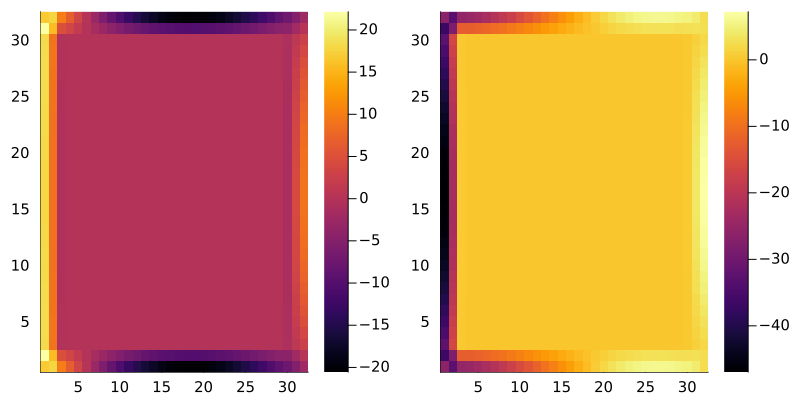

In [18]:
plt = plot(heatmap(check_real[l:r,l:r]),
        heatmap(check_imag[l:r,l:r]),
        labelfontsize=16,tickfontsize=10,size=(800,400),
        legendfontsize=8)

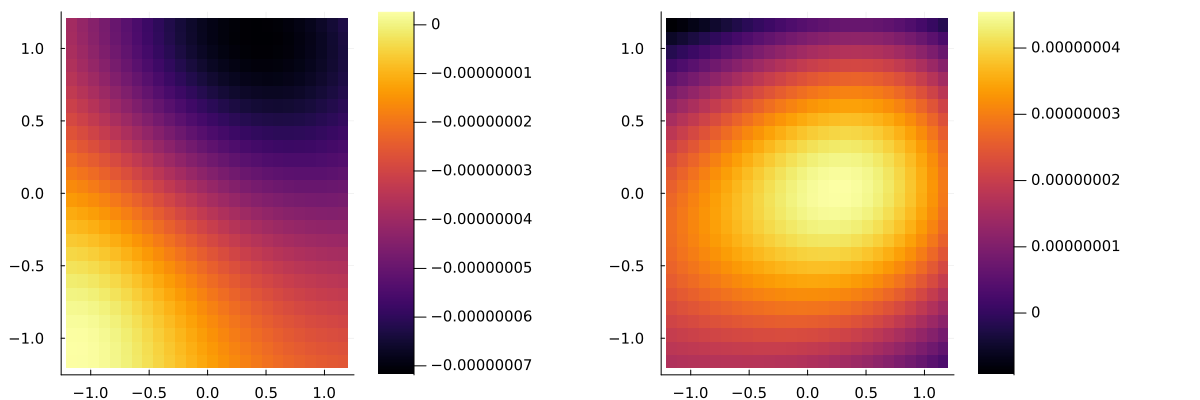

In [44]:
spatial_part = -len/2 + 2*dx:dx:len/2 - 2*dx 

plt = plot(heatmap(spatial_part, spatial_part, check_real[l+3:r-3,l+3:r-3],right_margin=3Plots.cm),
        heatmap(spatial_part, spatial_part, check_imag[l+3:r-3,l+3:r-3],right_margin=3Plots.cm),
        labelfontsize=16,tickfontsize=10,size=(1200,400),
        legendfontsize=8) 


#### The edges are messy for some reason, but we will not worry about this too much since we will switch to a circle which is smoother